<div align="center">
  <h1>R Implementation of Sampling Estimation on Vehicle Sales Database</h1>
  <p style="margin: 2px 0;"><b>Author: </b>Alexis Alberto Zúñiga Alonso</p>
  <p style="margin: 2px 0;"><b>Date: </b>September 23, 2026</p>
  <p style="margin: 2px 0;"><b>Course: </b>Statistical Models</p>
  <p style="margin: 2px 0;"><b>Institution: </b>EdgeHub | School of Innovation</p>
  <p style="margin: 2px 0;"><b>Degree: </b>B.Sc. in Artificial Intelligence</p>
  <p style="margin: 2px 0 16px 0;"><b>Prof.: </b>M.Sc. Axel Torres</p>
</div>

---

## Instructions:

This is the second part of the sampling assignment. The database is `car_prices.csv`, a record of vehicle auction sales with $N = 558{,}863$ rows, gathered for this assignment.

1. Set the seed with `set.seed(123)`.
2. Draw a sample of size $n = 50{,}000$.
3. Estimate the mean of the variable `sellingprice` for each type of sampling, and report its 95% confidence interval.

Since the point of this part is comparing sampling types, the same seed and the same target size ($n = 50{,}000$) are applied to four methods: simple random, systematic, stratified, and cluster sampling. These are the same general families of methods discussed in the sampling plan from Part 1.

## 1. Libraries

In [1]:
library(dplyr)

Attaching package: 'dplyr'

The following objects are masked from 'package:stats':

    filter, lag

The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union

## 2. Dataset Loading and Cleaning

### 2.1. Load Dataset

In [2]:
df_raw <- read.csv(file = "../data/car_prices.csv", header = TRUE, sep = ",", stringsAsFactors = FALSE)

print(head(df_raw))
cat("\n")
str(df_raw)

  year   make               model       trim  body transmission
1 2015    Kia             Sorento         LX   SUV    automatic
2 2015    Kia             Sorento         LX   SUV    automatic
3 2014    BMW            3 Series 328i SULEV Sedan    automatic
4 2015  Volvo                 S60         T5 Sedan    automatic
5 2014    BMW 6 Series Gran Coupe       650i Sedan    automatic
6 2015 Nissan              Altima      2.5 S Sedan    automatic
                vin state condition odometer color interior
1 5xyktca69fg566472    ca         5    16639 white    black
2 5xyktca69fg561319    ca         5     9393 white    beige
3 wba3c1c51ek116351    ca       4.5     1331  gray    black
4 yv1612tb4f1310987    ca       4.1    14282 white    black
5 wba6b2c57ed129731    ca       4.3     2641  gray    black
6 1n4al3ap1fn326013    ca         1     5554  gray    black
                                              seller   mmr sellingprice
1                            kia motors america, inc 20500  

### 2.2. Data cleaning

In [3]:
cat("Rows before cleaning:", nrow(df_raw), "\n")
cat("Missing sellingprice:", sum(is.na(df_raw$sellingprice)), "\n")
cat("Rows with a corrupted 'state' field (not a 2-letter code):", sum(nchar(df_raw$state) != 2), "\n")

df <- df_raw %>% filter(!is.na(sellingprice), nchar(state) == 2)
cat("Rows after cleaning:", nrow(df), "\n")

Rows before cleaning: 558863 
Missing sellingprice: 26 
Rows with a corrupted 'state' field (not a 2-letter code): 52 
Rows after cleaning: 558811 

## 3. Setting the Seed and the Sample Size

In [4]:
set.seed(123)
N <- nrow(df)
n <- 50000
cat("Population size (N):", N, "\n")
cat("Sample size (n):", n, "\n")

Population size (N): 558811 
Sample size (n): 50000 

## 4. Simple Random Sampling

In [5]:
srs_idx <- sample(seq_len(N), size = n, replace = FALSE)
srs_sample <- df[srs_idx, ]

srs_mean <- mean(srs_sample$sellingprice)
srs_ci <- t.test(srs_sample$sellingprice)$conf.int

cat("Simple Random Sample size:", nrow(srs_sample), "\n")
print(paste("Mean of sellingprice (SRS):", round(srs_mean, 2)))
print(paste("95% CI (SRS): [", round(srs_ci[1], 2), ",", round(srs_ci[2], 2), "]"))

Simple Random Sample size: 50000 
[1] "Mean of sellingprice (SRS): 13603.09"
[1] "95% CI (SRS): [ 13517.45 , 13688.74 ]"

##### Observations
- The SRS mean (13,603.09) lands almost exactly on the true population mean (13,611.26), off by less than $10.
- The 95% CI is fairly narrow (about $171 wide), as expected with a sample this large.

## 5. Systematic Sampling

In [6]:
k <- floor(N / n)
start <- sample(seq_len(k), 1)
sys_idx <- seq(from = start, to = N, by = k)[1:n]
sys_sample <- df[sys_idx, ]

sys_mean <- mean(sys_sample$sellingprice)
sys_ci <- t.test(sys_sample$sellingprice)$conf.int

cat("Sampling interval (k):", k, " | random start:", start, "\n")
cat("Systematic Sample size:", nrow(sys_sample), "\n")
print(paste("Mean of sellingprice (Systematic):", round(sys_mean, 2)))
print(paste("95% CI (Systematic): [", round(sys_ci[1], 2), ",", round(sys_ci[2], 2), "]"))

Sampling interval (k): 11  | random start: 5 
Systematic Sample size: 50000 
[1] "Mean of sellingprice (Systematic): 13642.96"
[1] "95% CI (Systematic): [ 13557.15 , 13728.76 ]"

##### Observations
- With $k = 11$, systematic sampling behaves almost exactly like SRS here, since the rows in the raw file are not ordered in any way that lines up with an 11-row cycle.
- The mean (13,642.96) and CI width are close to the SRS ones, which is the expected result when there is no hidden periodicity in the data.

## 6. Stratified Sampling (Proportional Allocation by State)

In [7]:
strata <- df %>%
  count(state, name = "Nh") %>%
  mutate(Wh = Nh / N, nh = round(Wh * n))

drift <- n - sum(strata$nh)
strata$nh[which.max(strata$Nh)] <- strata$nh[which.max(strata$Nh)] + drift

cat("Number of strata (states):", nrow(strata), "\n")
cat("Total allocated after rounding fix:", sum(strata$nh), "\n")
print(head(strata %>% arrange(desc(Nh)), 8))

Number of strata (states): 38 
Total allocated after rounding fix: 50000 
  state    Nh         Wh   nh
1    fl 82945 0.14843122 7424
2    ca 73148 0.13089936 6545
3    pa 53907 0.09646732 4823
4    tx 45913 0.08216195 4108
5    ga 34750 0.06218560 3109
6    nj 27784 0.04971985 2486
7    il 23486 0.04202852 2101
8    nc 21845 0.03909193 1955

In [8]:
strat_sample <- df %>%
  group_by(state) %>%
  group_modify(~ {
    nh <- strata$nh[strata$state == .y$state]
    .x[sample(seq_len(nrow(.x)), size = min(nh, nrow(.x))), ]
  }) %>%
  ungroup()

strat_mean <- mean(strat_sample$sellingprice)
strat_ci <- t.test(strat_sample$sellingprice)$conf.int

cat("Stratified Sample size:", nrow(strat_sample), "\n")
print(paste("Mean of sellingprice (Stratified):", round(strat_mean, 2)))
print(paste("95% CI (Stratified): [", round(strat_ci[1], 2), ",", round(strat_ci[2], 2), "]"))

Stratified Sample size: 50000 
[1] "Mean of sellingprice (Stratified): 13601.6"
[1] "95% CI (Stratified): [ 13516.45 , 13686.75 ]"

##### Observations
- Only 38 of the roughly 50 valid state codes end up with a nonzero quota; the smallest states round down to zero cars and simply drop out of the sample. That is a real limitation of proportional allocation once there are many tiny strata.
- Florida and California alone make up close to 28% of the sample, matching their share of the population.
- The mean (13,601.60) and the CI width (170.30) are both close to the SRS numbers. Since `sellingprice` does not vary dramatically by state, stratifying by state does not buy much extra precision in this case, even though the underlying logic is sound.

## 7. Cluster Sampling (Two-Stage: Manufacturer, then Car)

In [9]:
df$make_clean <- tolower(trimws(df$make))
all_clusters <- sample(unique(df$make_clean))

selected <- c()
pool <- df[0, ]
for (cl in all_clusters) {
  selected <- c(selected, cl)
  pool <- df[df$make_clean %in% selected, ]
  if (nrow(pool) >= n) break
}

clus_sample <- pool[sample(seq_len(nrow(pool)), size = n), ]

clus_mean <- mean(clus_sample$sellingprice)
clus_ci <- t.test(clus_sample$sellingprice)$conf.int

cat("Clusters (manufacturers) selected in stage 1:", length(selected), "\n")
cat("Pooled rows from those clusters:", nrow(pool), "\n")
cat("Final subsample size (stage 2):", nrow(clus_sample), "\n")
print(paste("Mean of sellingprice (Cluster):", round(clus_mean, 2)))
print(paste("95% CI (Cluster): [", round(clus_ci[1], 2), ",", round(clus_ci[2], 2), "]"))

Clusters (manufacturers) selected in stage 1: 12 
Pooled rows from those clusters: 63984 
Final subsample size (stage 2): 50000 
[1] "Mean of sellingprice (Cluster): 14825.84"
[1] "95% CI (Cluster): [ 14721.13 , 14930.55 ]"

##### Observations
- Only 12 manufacturers ended up selected before the pool passed 50,000 cars, and that is exactly why the estimate is off.
- The mean jumps to 14,825.84, about $1,200 above the true population mean, and its own 95% CI (\[14,721.13, 14,930.55\]) does not even contain the population mean.
- This is not a bug, it is the textbook risk of cluster sampling: whichever manufacturers happen to get drawn pull the whole estimate toward their own price level. Subsampling within the selected clusters does not fix that, since the bias comes from *which* clusters got picked, not from how many cars get taken out of them.

## 8. Population Values (for Reference)

In [10]:
pop_mean <- mean(df$sellingprice)
pop_ci <- t.test(df$sellingprice)$conf.int
print(paste("Population mean of sellingprice:", round(pop_mean, 2)))
print(paste("Population 95% CI: [", round(pop_ci[1], 2), ",", round(pop_ci[2], 2), "]"))

[1] "Population mean of sellingprice: 13611.26"
[1] "Population 95% CI: [ 13585.7 , 13636.83 ]"

## 9. Comparison

In [11]:
comparison <- data.frame(
  Method = c("Simple Random", "Systematic", "Stratified", "Cluster (2-stage)", "Population (true)"),
  n = c(nrow(srs_sample), nrow(sys_sample), nrow(strat_sample), nrow(clus_sample), N),
  Mean = round(c(srs_mean, sys_mean, strat_mean, clus_mean, pop_mean), 2),
  CI_Lower = round(c(srs_ci[1], sys_ci[1], strat_ci[1], clus_ci[1], pop_ci[1]), 2),
  CI_Upper = round(c(srs_ci[2], sys_ci[2], strat_ci[2], clus_ci[2], pop_ci[2]), 2)
)
comparison$CI_Width <- round(comparison$CI_Upper - comparison$CI_Lower, 2)
print(comparison)

             Method      n     Mean CI_Lower CI_Upper CI_Width
1     Simple Random  50000 13603.09 13517.45 13688.74   171.29
2        Systematic  50000 13642.96 13557.15 13728.76   171.61
3        Stratified  50000 13601.60 13516.45 13686.75   170.30
4 Cluster (2-stage)  50000 14825.84 14721.13 14930.55   209.42
5 Population (true) 558811 13611.26 13585.70 13636.83    51.13

### 9.1. Visual Comparison (Extra)

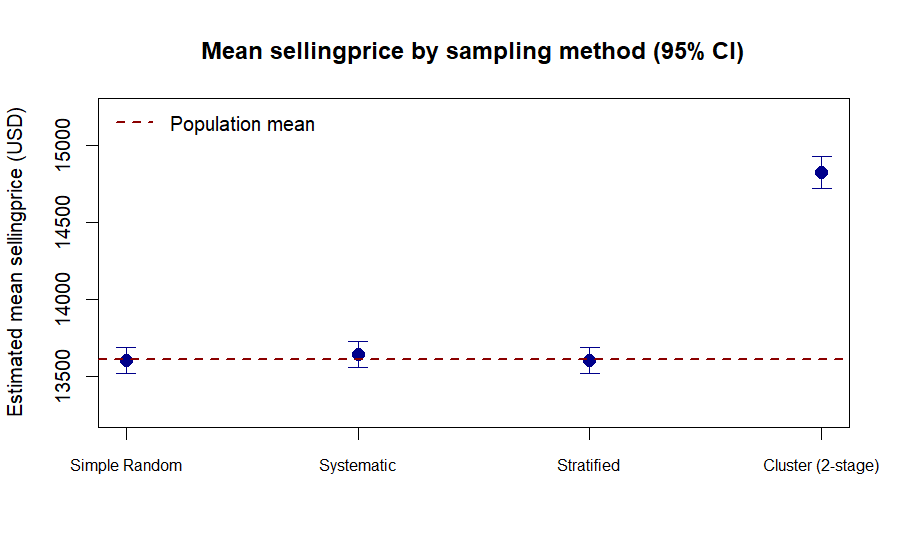

In [12]:
options(repr.plot.width = 7.5, repr.plot.height = 4.58)

methods <- comparison$Method[1:4]
means   <- comparison$Mean[1:4]
lower   <- comparison$CI_Lower[1:4]
upper   <- comparison$CI_Upper[1:4]

plot(1:4, means, ylim = range(c(lower, upper, pop_mean)) * c(0.98, 1.02),
     xaxt = "n", xlab = "", ylab = "Estimated mean sellingprice (USD)",
     main = "Mean sellingprice by sampling method (95% CI)",
     pch = 19, col = "darkblue", cex = 1.4)
axis(1, at = 1:4, labels = methods, cex.axis = 0.8)
arrows(1:4, lower, 1:4, upper, angle = 90, code = 3, length = 0.08, col = "darkblue")
abline(h = pop_mean, col = "darkred", lty = 2, lwd = 2)
legend("topleft", legend = "Population mean", col = "darkred", lty = 2, lwd = 2, bty = "n")

## 10. Interpretation of Results

| Method | n | Mean | 95% CI | CI Width |
|---|---|---|---|---|
| Simple Random | 50,000 | 13,603.09 | [13,517.45, 13,688.74] | 171.29 |
| Systematic | 50,000 | 13,642.96 | [13,557.15, 13,728.76] | 171.61 |
| Stratified | 50,000 | 13,601.60 | [13,516.45, 13,686.75] | 170.30 |
| Cluster (2-stage) | 50,000 | 14,825.84 | [14,721.13, 14,930.55] | 209.42 |
| **Population (true)** | 558,811 | **13,611.26** | [13,585.70, 13,636.83] | 51.13 |

A few conclusions come out of this comparison:

1. Simple random, systematic, and stratified sampling all land within about $40 of each other and within roughly $10 to $30 of the true population mean. Their confidence intervals are also nearly the same width, since none of them buys much precision over plain random sampling for this particular variable.
2. Cluster sampling is the clear outlier. Because manufacturers differ a lot in typical selling price, whichever ones happen to get drawn pull the whole sample average toward their own price range. In this run the estimate came in about $1,200 too high, badly enough that its own 95% CI does not contain the true value.
3. This is the same risk that the two-stage design from Part 1 needs to guard against. Schools are clusters in exactly this sense: if ADHD screening rates differ systematically between schools (different neighborhoods, resources, or screening practices), a poorly sized or poorly stratified sample of schools could produce the same kind of bias seen here with manufacturers. Stratifying schools by municipality and type before selecting them, as proposed in Part 1, is precisely what keeps that risk in check.
4. A caveat on the confidence intervals: all four were computed with the same simple formula (`t.test`), which assumes independent, equal-probability draws. That assumption does not really hold for stratified or cluster sampling. A fully rigorous analysis would use design-based standard errors that account for strata weights and within-cluster correlation. The same formula was used everywhere here so the four estimates would be directly comparable, but for the cluster case in particular, this naive CI understates how uncertain that estimate really is, since the actual source of error (which manufacturers got picked) is not the kind of variability a within-sample formula can see.